# **Training a diffusion model** 💫
___

**!!! This is a great tutorial series to understand diffusion models - please have a look at it !!!**

Loosely based on this tutorial series

https://huggingface.co/learn/diffusion-course/en/unit0/1

___
## **Preparing the dataset**

First we need to download and prepare the dataset

In [1]:
!mkdir dataset

___
We get a prepared dataset form https://huggingface.co/datasets/Cybernaut101/floorplans_subset_10000_simple_labels

In [2]:
from huggingface_hub import snapshot_download

# Download the dataset
snapshot_download(repo_id="Cybernaut101/floorplan_dataset_images_10000_simple_labels", repo_type="dataset", local_dir=r"dataset")

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.02M [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

'/content/dataset'

___
Now we need a to create a dataset and a dataloader.
This is there to load random datapoints from the dataset for the training process.

In [7]:
from datasets import load_dataset
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision
from PIL import Image

class FloorplanDataset(Dataset):
    def __init__(self, data_dir="dataset", split="train", transform=None):
        # Load from local directory instead of HuggingFace Hub
        self.ds = load_dataset(data_dir, split=split)
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample = self.ds[idx]

        # Convert to PIL Image for torchvision transforms
        room_instances = np.array(sample["room_labels"], dtype=np.uint8)
        image = Image.fromarray(room_instances, mode='L')

        if self.transform:
            image = self.transform(image)

        return image


___
Let's have a look at one datasample. The Transforms are applied to make sure that the the images are rotated and flipped randomly, since there are no difference in this on our dataset and so we can enrich the dataset further.

In [ ]:
from PIL.Image import Transform
import matplotlib.pyplot as plt

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomVerticalFlip(p=0.5),
    torchvision.transforms.RandomChoice([
        torchvision.transforms.RandomRotation([0, 0]),
        torchvision.transforms.RandomRotation([90, 90]),
        torchvision.transforms.RandomRotation([180, 180]),
        torchvision.transforms.RandomRotation([270, 270]),
    ]),
    torchvision.transforms.Normalize([0.5], [0.5]),
])

dataset = FloorplanDataset(data_dir="dataset", split="train", transform=transform)
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# Get random sample using iter/next
sample = next(iter(dataloader)).unsqueeze(0)

___
Now let's visualize a random datapoint

/tmp/ipython-input-793068945.py:22: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(room_instances, mode='L')


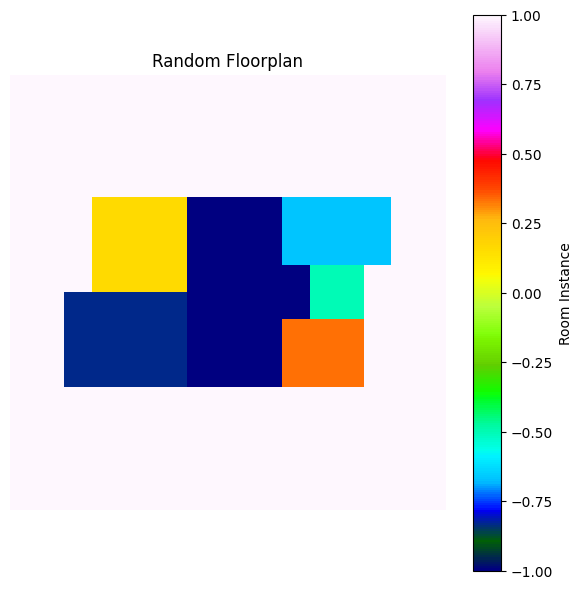

In [11]:


# Plot (squeeze batch and channel dims)
plt.figure(figsize=(6, 6))
plt.imshow(sample.squeeze().numpy(), cmap="gist_ncar")
plt.colorbar(label="Room Instance")
plt.title("Random Floorplan")
plt.axis("off")
plt.tight_layout()
plt.show()

In [12]:
print(f"Shortened tensor:\n\n{sample}")
print("\n\n")
print(f"Sample tensor shape\n\n{sample.shape}")

Shortened tensor:

tensor([[[[[1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           ...,
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.],
           [1., 1., 1.,  ..., 1., 1., 1.]]]]])



Sample tensor shape

torch.Size([1, 1, 1, 32, 32])


___
## **Setting up the diffusion model**


First we install and load some libraries needed to train diffusion models

In [13]:
!pip install -q diffusers

In [14]:
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler
from diffusers.training_utils import EMAModel
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import copy

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [15]:
# Load dataset with shuffle and transforms
dataset = FloorplanDataset(data_dir="dataset", split="train", transform=transform)

This block defines the Unet (the actual neural network) and sets the Hyperparameters 💫

In [59]:
# Hyperparameters
batch_size = 128 # This is how many images are pushed through the model in parallel during training

n_epochs = 50  # More epochs for better convergence - IMPORTANT HYPERPARAMETER - more epochs can improve training

num_train_timesteps = 1000 # This is how many diffusion steps are taken during training

train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Larger UNet2DModel with more capacity
net = UNet2DModel(
    sample_size=32,
    in_channels=1,
    out_channels=1,

    layers_per_block=4,  # More layers per block

    # More channels for better capacity
    block_out_channels=(128, 256, 512), # IMPORTANT HYPERPARAMETER - more layers can improve training

    # Attention at multiple resolutions
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),

    attention_head_dim=8, # IMPORTANT HYPERPARAMETER - higher can improve training
    norm_num_groups=32,
    downsample_padding=1,
    act_fn="silu",
    resnet_time_scale_shift="default",
)
net.to(device)

# EMA for smoother, higher-quality samples
ema = EMAModel(
    net.parameters(),
    decay=0.9999,
    use_ema_warmup=True,
    inv_gamma=1.0,
    power=0.75,
)
ema.to(device)

# Use DDPM scheduler for training
noise_scheduler = DDPMScheduler(
    num_train_timesteps=num_train_timesteps,
    beta_schedule="squaredcos_cap_v2",
)

# Optimizer
optimizer = torch.optim.AdamW(net.parameters(), lr=1e-4, weight_decay=1e-6)

# Learning rate scheduler with warmup
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-4,
    total_steps=n_epochs * len(train_dataloader),
    pct_start=0.05,  # 5% warmup
)

# Loss function
loss_fn = nn.MSELoss()

Now let's run the training loop! ⭕


In [60]:
# Training loop
losses = []
for epoch in tqdm(range(n_epochs), desc="Epochs"):
    epoch_losses = []
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch}", leave=False)

    for x in progress_bar:
        x = x.to(device)

        # Sample random timesteps
        timesteps = torch.randint(
            0, num_train_timesteps, (x.shape[0],), device=device
        ).long()

        # Sample noise
        noise = torch.randn_like(x)

        # Add noise
        noisy_x = noise_scheduler.add_noise(x, noise, timesteps)

        # Predict noise
        noise_pred = net(noisy_x, timesteps).sample

        # Loss
        loss = loss_fn(noise_pred, noise)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        lr_scheduler.step()

        # Update EMA
        ema.step(net.parameters())

        losses.append(loss.item())
        epoch_losses.append(loss.item())
        progress_bar.set_postfix(loss=f"{loss.item():.5f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f'Epoch {epoch}: avg loss = {avg_loss:.5f}, lr = {lr_scheduler.get_last_lr()[0]:.6f}')

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0:   0%|          | 0/79 [00:00<?, ?it/s]

/tmp/ipython-input-793068945.py:22: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(room_instances, mode='L')


Epoch 0: avg loss = 0.29707, lr = 0.000075


Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 47: avg loss = 0.01061, lr = 0.000001


Epoch 48:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 48: avg loss = 0.01077, lr = 0.000000


Epoch 49:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 49: avg loss = 0.01068, lr = 0.000000


___
With this code we can create samples and visualize the results created from our model

Generating samples with EMA weights...


Sampling:   0%|          | 0/100 [00:00<?, ?it/s]

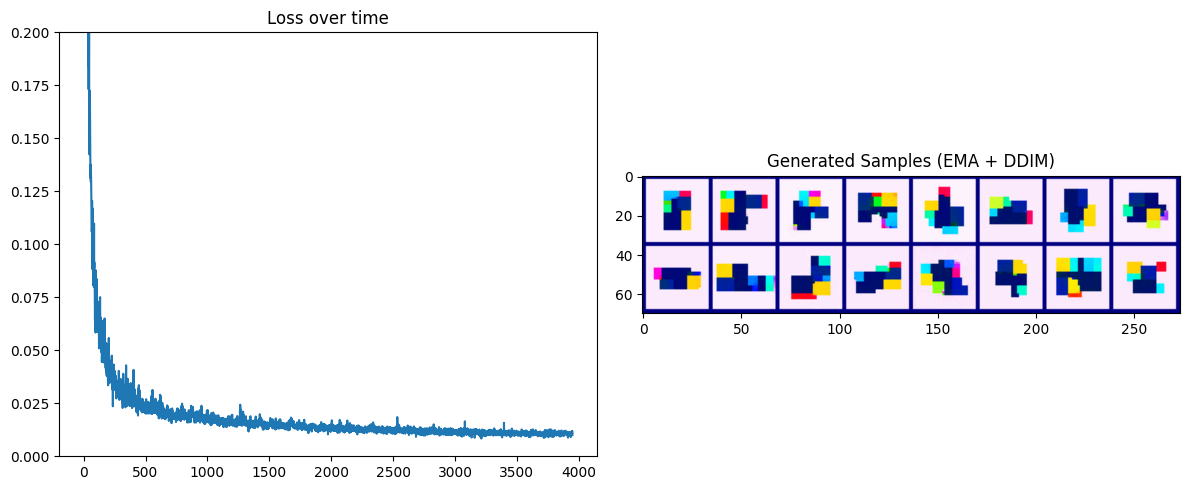

In [105]:
# ============ SAMPLING ============
net.eval()

def sample(model, scheduler, n_samples=64, num_inference_steps=100):
    """Generate samples using DDPM or DDIM sampling"""
    scheduler.set_timesteps(num_inference_steps)

    sample = torch.randn(n_samples, 1, 32, 32).to(device)

    for t in tqdm(scheduler.timesteps, desc="Sampling", leave=False):
        with torch.no_grad():
            noise_pred = model(sample, t).sample
        sample = scheduler.step(noise_pred, t, sample).prev_sample

    return sample

# Sample with EMA weights (typically better quality)
ema.copy_to(net.parameters())

# Use DDIM for faster sampling (can use fewer steps)
ddim_scheduler = DDIMScheduler(
    num_train_timesteps=num_train_timesteps,
    beta_schedule="squaredcos_cap_v2",
)

# Generate samples
print("Generating samples with EMA weights...")
samples = sample(net, ddim_scheduler, n_samples=16, num_inference_steps=100)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(losses)
axs[0].set_ylim(0, 0.2)
axs[0].set_title('Loss over time')

samples_display = (samples.cpu() + 1) / 2
axs[1].imshow(
    torchvision.utils.make_grid(samples_display, nrow=8)[0].clip(0, 1),
    cmap='gist_ncar'
)
axs[1].set_title('Generated Samples (EMA + DDIM)')
plt.tight_layout()
plt.show()

## **Sampling from the trained model**
___

### Helpermethods
Some helper models to clean the ouptut and visualize samples

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


def segment_with_labels(image, tolerance=10):
    """
    Segment image into regions by comparing neighboring pixels.
    Prevents overspill by only grouping pixels that are similar to their neighbors.

    Args:
        image: 2D numpy array
        tolerance: Maximum difference between NEIGHBORING pixels to be in same region

    Returns:
        labels: Array where each region has a unique integer ID (starting from 1)
        stats: Dict with region info (mean, size, etc.)
    """
    h, w = image.shape
    labels = np.zeros((h, w), dtype=np.int32)
    current_label = 0

    def flood_fill_neighbor_compare(start_y, start_x, label_id):
        """
        Flood fill that compares each pixel to the neighbor it came from,
        not to the original starting pixel.
        """
        # Stack contains (y, x, value_of_neighbor_we_came_from)
        stack = [(start_y, start_x, image[start_y, start_x])]
        region_pixels = []

        while stack:
            y, x, neighbor_val = stack.pop()

            if y < 0 or y >= h or x < 0 or x >= w:
                continue
            if labels[y, x] != 0:  # Already labeled
                continue

            current_val = image[y, x]

            # Compare to the neighbor we came from
            if abs(float(current_val) - float(neighbor_val)) > tolerance:
                continue

            labels[y, x] = label_id
            region_pixels.append((y, x))

            # Add neighbors, passing current pixel's value as reference
            stack.extend([
                (y-1, x, current_val),
                (y+1, x, current_val),
                (y, x-1, current_val),
                (y, x+1, current_val),
            ])

        return region_pixels

    stats = {}

    # Find all regions
    for y in range(h):
        for x in range(w):
            if labels[y, x] == 0:
                current_label += 1
                region = flood_fill_neighbor_compare(y, x, current_label)

                if len(region) > 0:
                    values = [image[py, px] for py, px in region]
                    stats[current_label] = {
                        'mean': np.mean(values),
                        'std': np.std(values),
                        'size': len(region),
                        'min': np.min(values),
                        'max': np.max(values),
                    }

    return labels, stats


def filter_small_regions(image, min_size=3, class_values=None):
    """
    Filter out small isolated regions and replace them with the most common
    neighboring value.

    Args:
        image: 2D numpy array (segmented image)
        min_size: Minimum region size in pixels. Regions smaller than this
                  will be replaced with neighboring values. Default is 3.
        class_values: Optional array of valid class values. If provided,
                      replacement values will be snapped to nearest class.

    Returns:
        Filtered image with small regions replaced by neighboring values
    """
    h, w = image.shape
    result = image.copy().astype(np.float32)

    # Find connected components using simple flood fill on exact values
    labels = np.zeros((h, w), dtype=np.int32)
    current_label = 0
    region_pixels = {}  # label -> list of (y, x)

    def flood_fill_exact(start_y, start_x, label_id, target_val):
        """Flood fill for exact value matching."""
        stack = [(start_y, start_x)]
        pixels = []

        while stack:
            y, x = stack.pop()

            if y < 0 or y >= h or x < 0 or x >= w:
                continue
            if labels[y, x] != 0:
                continue
            if result[y, x] != target_val:
                continue

            labels[y, x] = label_id
            pixels.append((y, x))

            stack.extend([
                (y-1, x), (y+1, x), (y, x-1), (y, x+1)
            ])

        return pixels

    # Label all regions
    for y in range(h):
        for x in range(w):
            if labels[y, x] == 0:
                current_label += 1
                pixels = flood_fill_exact(y, x, current_label, result[y, x])
                region_pixels[current_label] = pixels

    # Find and fix small regions
    for label_id, pixels in region_pixels.items():
        if len(pixels) < min_size:
            # Collect all neighboring values (from outside this region)
            neighbor_values = []

            for y, x in pixels:
                for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        if labels[ny, nx] != label_id:
                            neighbor_values.append(result[ny, nx])

            if neighbor_values:
                # Use most common neighbor value
                most_common = Counter(neighbor_values).most_common(1)[0][0]

                # Optionally snap to nearest class value
                if class_values is not None:
                    class_values_np = np.array(class_values)
                    nearest_idx = np.argmin(np.abs(class_values_np - most_common))
                    most_common = class_values_np[nearest_idx]

                # Replace all pixels in small region
                for y, x in pixels:
                    result[y, x] = most_common

    return result


def filter_small_regions_iterative(image, min_size=3, class_values=None, max_iterations=10):
    """
    Iteratively filter small regions until no more small regions exist.

    This handles cases where removing one small region might create or expose
    another small region.

    Args:
        image: 2D numpy array (segmented image)
        min_size: Minimum region size in pixels
        class_values: Optional array of valid class values
        max_iterations: Maximum number of filter passes

    Returns:
        Filtered image with all small regions removed
    """
    result = image.copy()

    for i in range(max_iterations):
        filtered = filter_small_regions(result, min_size, class_values)

        # Check if anything changed
        if np.array_equal(filtered, result):
            break

        result = filtered

    return result


def segment_and_average(image, tolerance=10, min_region_size=1):
    """
    Find connected regions and replace each with its average value.

    Args:
        image: 2D numpy array (H, W)
        tolerance: Maximum difference between neighboring pixels
        min_region_size: Minimum pixels for a region (smaller regions keep original values)

    Returns:
        Array with each region replaced by its average value
    """
    labels, stats = segment_with_labels(image, tolerance)
    result = image.copy().astype(np.float32)

    for region_id, info in stats.items():
        if info['size'] >= min_region_size:
            mask = labels == region_id
            result[mask] = info['mean']

    return result


def segment_and_round_to_classes(image, class_values, tolerance=10, min_region_size=1):
    """
    Segment image and round each region's average to nearest class value.

    Args:
        image: 2D numpy array
        class_values: List/array of valid class values
        tolerance: Max difference between neighboring pixels
        min_region_size: Minimum pixels for a region

    Returns:
        Array with each region assigned to nearest class
    """
    class_values = np.array(class_values)
    labels, stats = segment_with_labels(image, tolerance)

    result = image.copy().astype(np.float32)
    for region_id, info in stats.items():
        if info['size'] >= min_region_size:
            # Find nearest class value to region mean
            avg = info['mean']
            nearest_idx = np.argmin(np.abs(class_values - avg))
            nearest_class = class_values[nearest_idx]

            mask = labels == region_id
            result[mask] = nearest_class

    return result


def segment_round_and_filter(image, class_values, tolerance=10, min_region_size=3):
    """
    Complete pipeline: segment, round to classes, and filter small regions.

    This combines segmentation with class rounding and small region filtering
    in one convenient function.

    Args:
        image: 2D numpy array
        class_values: List/array of valid class values (e.g., [0, 21, 42, ...])
        tolerance: Max difference between neighboring pixels for segmentation
        min_region_size: Regions smaller than this will be merged with neighbors

    Returns:
        Clean segmented image with no small isolated regions
    """
    # First segment and round to classes
    segmented = segment_and_round_to_classes(image, class_values, tolerance, min_region_size=1)

    # Then filter out any remaining small regions
    filtered = filter_small_regions_iterative(segmented, min_region_size, class_values)

    return filtered


def visualize_segmentation(original, segmented, labels=None, class_values=None, class_names=None):
    """Show original, segmented, and optionally labeled regions."""
    n_plots = 3 if labels is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(segmented, cmap='gray')
    axes[1].set_title('Segmented (averaged)')
    axes[1].axis('off')

    if labels is not None:
        axes[2].imshow(labels, cmap='gist_ncar')
        axes[2].set_title(f'Labels ({labels.max()} regions)')
        axes[2].axis('off')

    plt.tight_layout()
    plt.show()


def create_class_colormap(class_values, cmap_name='gist_ncar'):
    """
    Create a colormap that consistently maps class values to colors.

    Args:
        class_values: Array of valid class values
        cmap_name: Name of the base colormap to use

    Returns:
        cmap: ListedColormap with colors for each class
        norm: BoundaryNorm for mapping values to colors
        colors: Dict mapping class values to RGB colors
    """
    from matplotlib.colors import ListedColormap, BoundaryNorm

    class_values = np.array(class_values)
    n_classes = len(class_values)

    # Get colors from base colormap, evenly spaced
    base_cmap = plt.colormaps.get_cmap(cmap_name)
    colors_list = [base_cmap(i / (n_classes - 1)) for i in range(n_classes)]

    # Create listed colormap
    cmap = ListedColormap(colors_list)

    # Create boundaries halfway between class values
    boundaries = []
    boundaries.append(class_values[0] - 1)  # Below first class
    for i in range(len(class_values) - 1):
        boundaries.append((class_values[i] + class_values[i + 1]) / 2)
    boundaries.append(class_values[-1] + 1)  # Above last class

    norm = BoundaryNorm(boundaries, cmap.N)

    # Create color dict for legend
    colors_dict = {val: colors_list[i] for i, val in enumerate(class_values)}

    return cmap, norm, colors_dict


def visualize_filtering(original, before_filter, after_filter, class_values=None, class_names=None):
    """
    Visualize the effect of small region filtering.

    Args:
        original: Original input image
        before_filter: Image before filtering
        after_filter: Image after filtering
        class_values: Array of valid class values for consistent coloring
        class_names: List of names for each class (for legend)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    if class_values is not None:
        cmap, norm, colors_dict = create_class_colormap(class_values)
        axes[1].imshow(before_filter, cmap=cmap, norm=norm)
        axes[2].imshow(after_filter, cmap=cmap, norm=norm)
    else:
        axes[1].imshow(before_filter, cmap='gray')
        axes[2].imshow(after_filter, cmap='gray')

    axes[1].set_title('Before Filtering')
    axes[1].axis('off')

    axes[2].set_title('After Filtering')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()


def visualize_segmentation_with_legend(image, class_values, class_names, title='Segmentation Result',
                                        cmap_name='gist_ncar', figsize=(12, 8)):
    """
    Visualize a segmented image with a legend showing room types and their colors.

    Args:
        image: 2D numpy array (segmented image with class values)
        class_values: Array of valid class values
        class_names: List of names for each class
        title: Title for the plot
        cmap_name: Name of colormap to use (default: 'gist_ncar')
        figsize: Figure size tuple

    Returns:
        fig, ax: Matplotlib figure and axis objects
    """
    from matplotlib.patches import Patch

    class_values = np.array(class_values)
    cmap, norm, colors_dict = create_class_colormap(class_values, cmap_name)

    # Find which classes are present in the image
    unique_vals = np.unique(image)
    present_classes = [(val, class_names[i]) for i, val in enumerate(class_values)
                       if val in unique_vals]

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    im = ax.imshow(image, cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.axis('off')

    # Create legend patches for present classes
    legend_patches = []
    for val, name in present_classes:
        color = colors_dict[val]
        patch = Patch(facecolor=color, edgecolor='black', label=f'{name} ({int(val)})')
        legend_patches.append(patch)

    # Add legend outside the plot
    ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
              title='Room Types', fontsize=9)

    plt.tight_layout()
    return fig, ax


def visualize_pipeline_with_legend(original, segmented, filtered, class_values, class_names,
                                    cmap_name='gist_ncar', figsize=(18, 6)):
    """
    Visualize the complete pipeline: original -> segmented -> filtered with legend.

    Args:
        original: Original input image
        segmented: Image after segmentation (before filtering)
        filtered: Final filtered image
        class_values: Array of valid class values
        class_names: List of names for each class
        cmap_name: Name of colormap to use
        figsize: Figure size tuple

    Returns:
        fig: Matplotlib figure object
    """
    from matplotlib.patches import Patch

    class_values = np.array(class_values)
    cmap, norm, colors_dict = create_class_colormap(class_values, cmap_name)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # Original (grayscale)
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    # Segmented (colored)
    axes[1].imshow(segmented, cmap=cmap, norm=norm)
    axes[1].set_title('Segmented')
    axes[1].axis('off')

    # Filtered (colored)
    axes[2].imshow(filtered, cmap=cmap, norm=norm)
    axes[2].set_title('Filtered')
    axes[2].axis('off')

    # Find which classes are present in any of the segmented images
    all_vals = np.concatenate([np.unique(segmented), np.unique(filtered)])
    unique_vals = np.unique(all_vals)
    present_classes = [(val, class_names[i]) for i, val in enumerate(class_values)
                       if val in unique_vals]

    # Create legend patches
    legend_patches = []
    for val, name in present_classes:
        color = colors_dict[val]
        patch = Patch(facecolor=color, edgecolor='black', label=f'{name} ({int(val)})')
        legend_patches.append(patch)

    # Add legend to the right of the figure
    fig.legend(handles=legend_patches, loc='center right', bbox_to_anchor=(0.99, 0.5),
               title='Room Types', fontsize=9)

    plt.tight_layout()
    plt.subplots_adjust(right=0.82)  # Make room for legend

    return fig

### Visualization

Visualizing and cleaning samples

This are our classes and the according values

In [126]:

# Valid color values for each class
CLASS_VALUES = torch.tensor([
    0, 21, 42, 63, 85, 106, 127, 148, 170, 191, 212, 233, 255
])

CLASS_NAMES = [
    "Living Room", "Master Room", "Kitchen", "Bathroom", "Dining Room", "Child Room", "Study Room", "Second Room", "Guest Room", "Balcony", "Entrance", "Storage", "External Area"
]

___
Here we sample take a single sample, bring it back to the CPU, clean it and visualize it

In [135]:
index = 5

single_sample = samples[index].squeeze().cpu().numpy()
single_sample = ((single_sample + 1) / 2) * 255
single_sample.shape

(32, 32)


Generating visualization with legend...


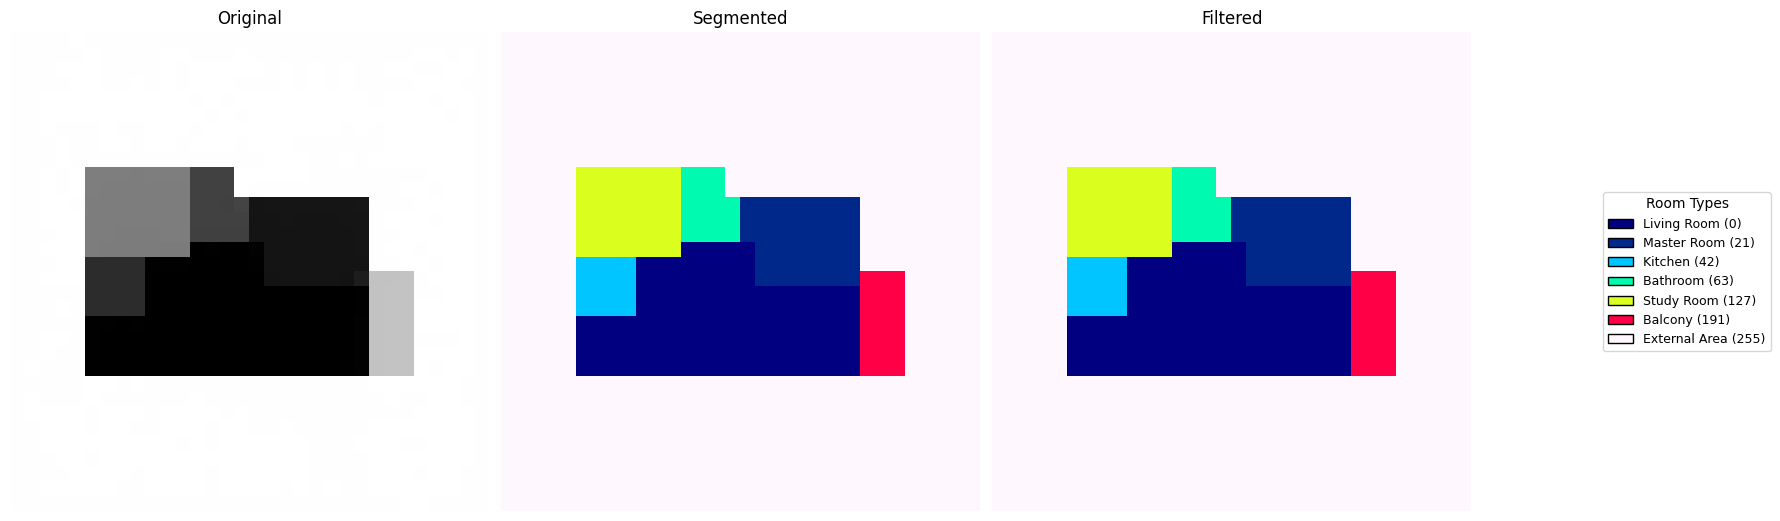

In [136]:
# Segment and round to classes first
segmented = segment_and_round_to_classes(single_sample, CLASS_VALUES, tolerance=10)

# Filter small regions (< 3 pixels)
filtered = filter_small_regions(segmented, min_size=3, class_values=CLASS_VALUES)

# Or use the complete pipeline
result = segment_round_and_filter(single_sample, CLASS_VALUES, tolerance=10, min_region_size=3)

# Visualize with legend
print("\nGenerating visualization with legend...")
fig = visualize_pipeline_with_legend(
    single_sample, segmented, filtered,
    CLASS_VALUES, CLASS_NAMES
)

In [132]:
result

array([[255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       ...,
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.],
       [255., 255., 255., ..., 255., 255., 255.]], dtype=float32)

## **Saving the trained model** 💾

This is code to save and download the trained model.
This can be unfortunately quite slow - so please be patient

In [146]:
from safetensors.torch import save_file
from google.colab import files
import pickle
import zipfile

# ===== SAVING & DOWNLOADING =====

# Save model weights
save_file(net.state_dict(), 'model.safetensors')

# Save EMA weights correctly - map shadow_params to parameter names
ema_state = {}
for i, (name, _) in enumerate(net.named_parameters()):
    ema_state[name] = ema.shadow_params[i]
save_file(ema_state, 'ema.safetensors')

# Save other training state
with open('training_state.pkl', 'wb') as f:
    pickle.dump({
        'epoch': epoch,
        'optimizer_state_dict': optimizer.state_dict(),
        'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        'losses': losses,
    }, f)

# Zip and download
with zipfile.ZipFile('checkpoint.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('model.safetensors')
    zf.write('ema.safetensors')
    zf.write('training_state.pkl')

files.download('checkpoint.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes
___

If you want to learn more about this, please have a look into this tutorial

https://huggingface.co/learn/diffusion-course/en/unit0/1


___
For even more vertical in depth I can highly recommend this tutorial series

https://www.youtube.com/watch?v=H45lF4sUgiE&list=PL8VDJoEXIjpo2S7X-1YKZnbHyLGyESDCe&index=1

Great 8 step tutorial series